In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score)

In [4]:
#load the dataset
df = pd.read_csv("placement_predict_50k Dataset.csv")
print(df.head())
print(df.shape)
print(df.columns)

   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterviewScore  \
0               66.7               2.2             49.4                47.8   


In [5]:
#Target (y) = survived
#to understand the data set
print(df.info())
print(df.describe())
print(df.isnull().sum())#check missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  object 
 2   City                50000 non-null  object 
 3   CollegeTier         50000 non-null  object 
 4   Stream              50000 non-null  object 
 5   Specialisation      50000 non-null  object 
 6   Hostel              50000 non-null  object 
 7   HistoryOfBacklogs   50000 non-null  object 
 8   SGPA_Sem1           50000 non-null  float64
 9   SGPA_Sem2           50000 non-null  float64
 10  SGPA_Sem3           50000 non-null  float64
 11  SGPA_Sem4           50000 non-null  float64
 12  SGPA_Sem5           50000 non-null  float64
 13  SGPA_Sem6           50000 non-null  float64
 14  SGPA_Sem7           50000 non-null  float64
 15  SGPA_Sem8           50000 non-null  float64
 16  CGPA

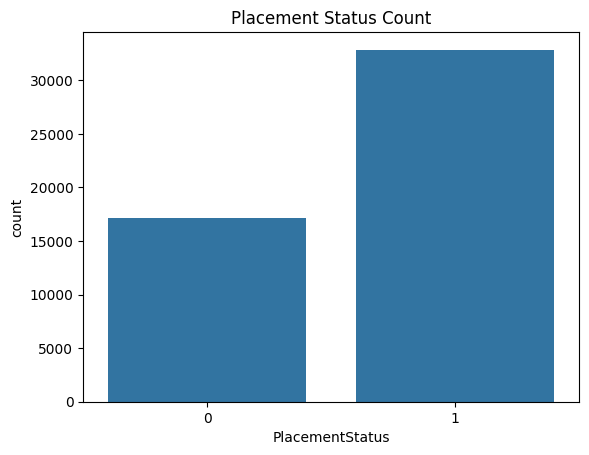

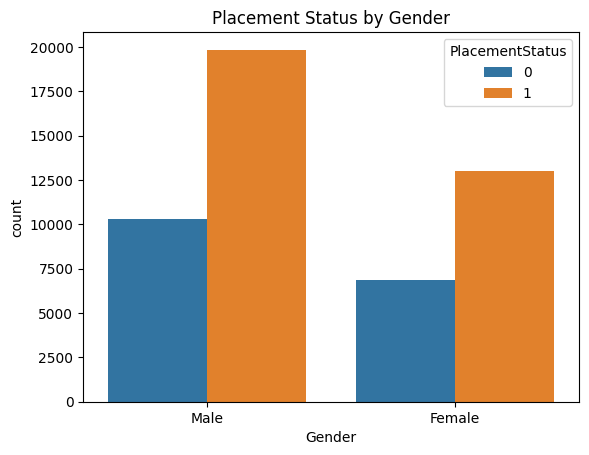

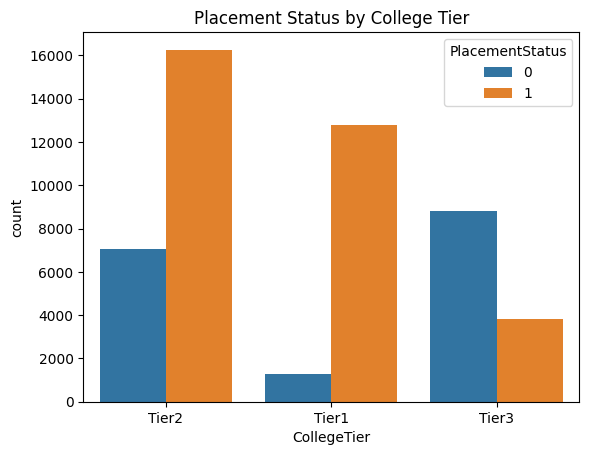

In [7]:
#EDA
sns.countplot(x="PlacementStatus", data=df)
plt.title("Placement Status Count")
plt.show()
#placement status by gender
sns.countplot(x="Gender", hue="PlacementStatus", data=df)
plt.title("Placement Status by Gender")
plt.show()
sns.countplot(x="CollegeTier", hue="PlacementStatus", data=df)
plt.title("Placement Status by College Tier")
plt.show()

In [9]:
#select the required features for placement prediction
# Numerical features (no missing values)
numerical_features = ['SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Certifications', 'Publications', 'ExtraCurricular']

# Numerical features (with missing values, to be imputed)
numerical_features_with_missing = ['Workshops', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore']

# Categorical features (to be one-hot encoded)
categorical_features = ['Gender', 'CollegeTier', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']

features = numerical_features + numerical_features_with_missing + categorical_features
X = df[features].copy()
y = df["PlacementStatus"]

# Impute missing values for numerical columns using median
for col in numerical_features_with_missing:
    X[col] = X[col].fillna(X[col].median())

print("Missing values after imputation:")
print(X.isnull().sum())

# Perform one-hot encoding for categorical columns
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)
print("\nFirst 5 rows of X after one-hot encoding:")
print(X.head())

Missing values after imputation:
SGPA_Sem1             0
SGPA_Sem2             0
SGPA_Sem3             0
SGPA_Sem4             0
SGPA_Sem5             0
SGPA_Sem6             0
SGPA_Sem7             0
SGPA_Sem8             0
CGPA                  0
AttendancePercent     0
Internships           0
Projects              0
Certifications        0
Publications          0
ExtraCurricular       0
Workshops             0
AptitudeTestScore     0
SoftSkillsRating      0
CodingTestScore       0
MockInterviewScore    0
Gender                0
CollegeTier           0
Hostel                0
HistoryOfBacklogs     0
CGPA_Tier             0
dtype: int64

First 5 rows of X after one-hot encoding:
   SGPA_Sem1  SGPA_Sem2  SGPA_Sem3  SGPA_Sem4  SGPA_Sem5  SGPA_Sem6  \
0       6.02       6.54       6.52       6.00       6.47       5.91   
1       5.84       5.12       5.34       5.18       5.03       4.93   
2       4.91       5.29       5.49       5.73       5.33       5.88   
3       7.67       8.03    

In [13]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
    random_state=42,stratify=y)
scaler = StandardScaler()

In [16]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
print("Model training completed")

y_pred = model.predict(X_test_scaled)
print(y_pred[:20])

Model training completed
[0 0 1 1 1 1 1 1 1 0 0 0 1 1 0 1 0 1 1 0]
